# Fruits and Vegetables Image Recognition Dataset

This project focuses on automated fruit and vegetable classification using deep learning. We first build and train a custom Convolutional Neural Network (CNN) from scratch to set a baseline. Next, we apply Transfer Learning using a pretrained architecture (e.g., ResNet50) to improve classification accuracy and performance. Finally, both approaches are evaluated and compared based on key performance metrics.

<img src='https://static.levels.com/_next/static/media/FruitsVeg_1800x1140.c2ea20e3.jpeg' width='750'>

In [5]:
#Libraries

import cv2
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Conv2D,Dense, Flatten, Input, MaxPooling2D, Dropout, BatchNormalization, Reshape
import os

import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.applications import VGG16, VGG19, ResNet50
import warnings
warnings.filterwarnings('ignore')

In [3]:
#!pip install kagglehub

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kritikseth/fruit-and-vegetable-image-recognition")

print("Path to dataset files:", path)

100%|█████████████████████████████████████████████████████████████████████████████| 1.98G/1.98G [03:43<00:00, 9.55MB/s]

Extracting files...


Path to dataset files: C:\Users\furka\.cache\kagglehub\datasets\kritikseth\fruit-and-vegetable-image-recognition\versions\8


### Reading Dataset

In [20]:
img_path = os.path.join(path, "train")

In [21]:
os.listdir(img_path)

['apple',
 'banana',
 'beetroot',
 'bell pepper',
 'cabbage',
 'capsicum',
 'carrot',
 'cauliflower',
 'chilli pepper',
 'corn',
 'cucumber',
 'eggplant',
 'garlic',
 'ginger',
 'grapes',
 'jalepeno',
 'kiwi',
 'lemon',
 'lettuce',
 'mango',
 'onion',
 'orange',
 'paprika',
 'pear',
 'peas',
 'pineapple',
 'pomegranate',
 'potato',
 'raddish',
 'soy beans',
 'spinach',
 'sweetcorn',
 'sweetpotato',
 'tomato',
 'turnip',
 'watermelon']

In [22]:
labels=['apple',
 'banana',
 'beetroot',
 'bell pepper',
 'cabbage',
 'capsicum',
 'carrot',
 'cauliflower',
 'chilli pepper',
 'corn',
 'cucumber',
 'eggplant',
 'garlic',
 'ginger',
 'grapes',
 'jalepeno',
 'kiwi',
 'lemon',
 'lettuce',
 'mango',
 'onion',
 'orange',
 'paprika',
 'pear',
 'peas',
 'pineapple',
 'pomegranate',
 'potato',
 'raddish',
 'soy beans',
 'spinach',
 'sweetcorn',
 'sweetpotato',
 'tomato',
 'turnip',
 'watermelon']

In [24]:
img_path = os.path.join(path, "train") + "/"

img_list = []
label_list = []
for label in labels:
    for img_file in os.listdir(img_path + label):
        img_list.append(img_path + label + '/' + img_file)
        label_list.append(label)

In [26]:
df=pd.DataFrame({'img':img_list,'label':label_list})

In [27]:
df.sample(10)

,img,label
2893,C:\Users\furka\.cache\kagglehub\datasets\kriti...,tomato
2387,C:\Users\furka\.cache\kagglehub\datasets\kriti...,potato
2725,C:\Users\furka\.cache\kagglehub\datasets\kriti...,sweetcorn
1837,C:\Users\furka\.cache\kagglehub\datasets\kriti...,orange
1726,C:\Users\furka\.cache\kagglehub\datasets\kriti...,onion
1150,C:\Users\furka\.cache\kagglehub\datasets\kriti...,ginger
1746,C:\Users\furka\.cache\kagglehub\datasets\kriti...,onion
1353,C:\Users\furka\.cache\kagglehub\datasets\kriti...,jalepeno
1374,C:\Users\furka\.cache\kagglehub\datasets\kriti...,kiwi
2522,C:\Users\furka\.cache\kagglehub\datasets\kriti...,soy beans


In [28]:
d = {
    'apple': 0,
    'banana': 1,
    'beetroot': 2,
    'bell pepper': 3,
    'cabbage': 4,
    'capsicum': 5,
    'carrot': 6,
    'cauliflower': 7,
    'chilli pepper': 8,
    'corn': 9,
    'cucumber': 10,
    'eggplant': 11,
    'garlic': 12,
    'ginger': 13,
    'grapes': 14,
    'jalepeno': 15,
    'kiwi': 16,
    'lemon': 17,
    'lettuce': 18,
    'mango': 19,
    'onion': 20,
    'orange': 21,
    'paprika': 22,
    'pear': 23,
    'peas': 24,
    'pineapple': 25,
    'pomegranate': 26,
    'potato': 27,
    'raddish': 28,
    'soy beans': 29,
    'spinach': 30,
    'sweetcorn': 31,
    'sweetpotato': 32,
    'tomato': 33,
    'turnip': 34,
    'watermelon': 35
}

In [29]:
df['label_encoded']=df['label'].map(d)

### EDA

In [31]:
df.sample(9)

,img,label,label_encoded
1148,C:\Users\furka\.cache\kagglehub\datasets\kriti...,ginger,13
2542,C:\Users\furka\.cache\kagglehub\datasets\kriti...,soy beans,29
2384,C:\Users\furka\.cache\kagglehub\datasets\kriti...,potato,27
643,C:\Users\furka\.cache\kagglehub\datasets\kriti...,cauliflower,7
1792,C:\Users\furka\.cache\kagglehub\datasets\kriti...,onion,20
921,C:\Users\furka\.cache\kagglehub\datasets\kriti...,cucumber,10
2840,C:\Users\furka\.cache\kagglehub\datasets\kriti...,sweetpotato,32
1604,C:\Users\furka\.cache\kagglehub\datasets\kriti...,lettuce,18
3114,C:\Users\furka\.cache\kagglehub\datasets\kriti...,watermelon,35


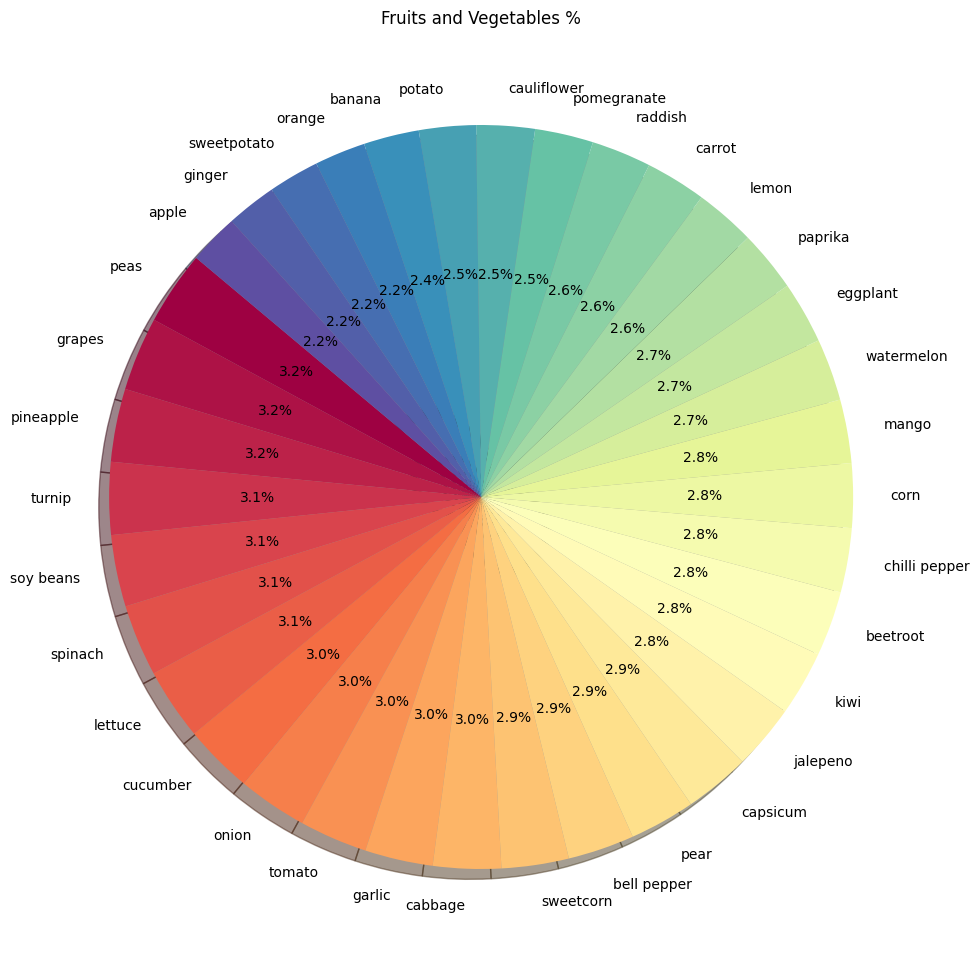

In [44]:
plt.figure(figsize=(12, 15))
df['label'].value_counts().plot.pie(autopct='%1.1f%%', shadow=True, cmap='Spectral', startangle=140)
plt.title("Fruits and Vegetables %")
plt.ylabel('')
plt.show()

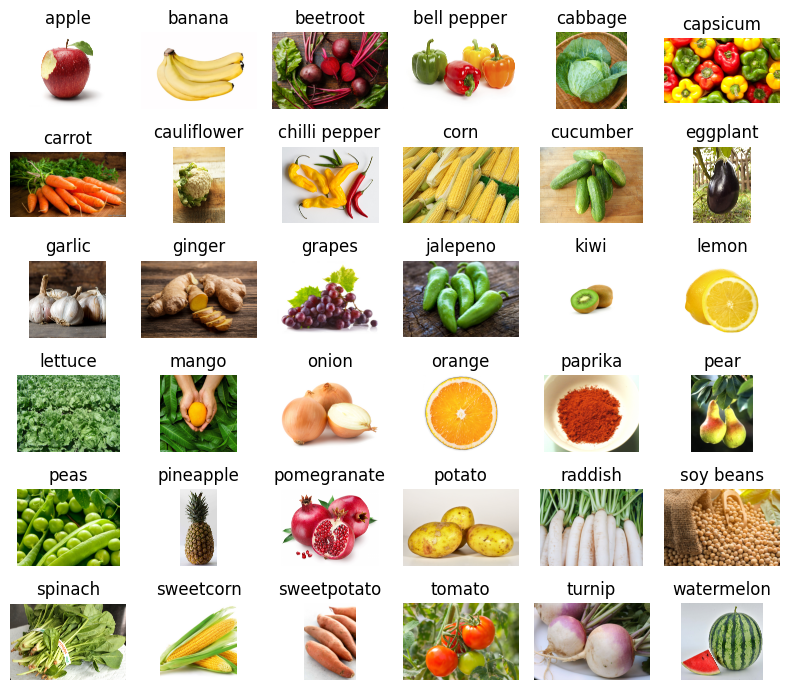

In [46]:
from PIL import Image
images = []
for label in labels:
    img_path = df[df['label'] == label]['img'].iloc[0]
    image = Image.open(img_path)
    images.append((image, label))
plt.figure(figsize=(8, 7))
for i, (image, label) in enumerate(images):
    plt.subplot(6, 6, i + 1)
    plt.imshow(image)
    plt.title(label)    
    plt.axis('off')
plt.tight_layout()
plt.show()

### Data Processing

In [50]:
x=[]
for img in df['img']:
    img=cv2.imread(str(img_path))
    img=cv2.resize(img,(170,170))
    img=img/255.0
    x.append(img)

In [51]:
x=np.array(x)

In [52]:
x.shape

(3115, 170, 170, 3)

In [54]:
1658*170*170*3

143748600

In [55]:
y=df[['label_encoded']]

### CNN Modelling


In [56]:
x_train,x_test,y_train,y_test=train_test_split(x,y, random_state=42, test_size=0.20)

In [57]:
y_train=np.array(y_train)
y_test=np.array(y_test)

In [97]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras import regularizers

model = Sequential()

model.add(Input(shape=(170, 170, 3)))

# Block 1
model.add(Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

# Block 2
model.add(Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

# Block 3
model.add(Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))

# Block 4
model.add(Conv2D(512, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.001)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))


model.add(GlobalAveragePooling2D())

# Classifier Head
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))


model.add(Dense(36, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3)]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 170, 170, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 170, 170, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 85, 85, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 85, 85, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 85, 85, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 42, 42, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 42, 42, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 42, 42, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 21, 21, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 21, 21, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 21, 21, 512)         │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 10, 10, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 36)                  │           9,252 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,695,396 (6.47 MB)

 Trainable params: 1,693,476 (6.46 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [59]:
early_stop = tf.keras.callbacks.EarlyStopping(patience=15,restore_best_weights=True)

In [60]:
history=model.fit(x_train,y_train, validation_data=(x_test,y_test), epochs=250, callbacks=[early_stop], verbose=1)

Epoch 1/250
78/78 ━━━━━━━━━━━━━━━━━━━━ 220s 3s/step - accuracy: 0.0277 - loss: 4.1521 - sparse_top_k_categorical_accuracy: 0.0787 - val_accuracy: 0.0385 - val_loss: 4.1850 - val_sparse_top_k_categorical_accuracy: 0.0899
Epoch 2/250
78/78 ━━━━━━━━━━━━━━━━━━━━ 222s 3s/step - accuracy: 0.0285 - loss: 3.8768 - sparse_top_k_categorical_accuracy: 0.0859 - val_accuracy: 0.0385 - val_loss: 4.3078 - val_sparse_top_k_categorical_accuracy: 0.0947
Epoch 3/250
78/78 ━━━━━━━━━━━━━━━━━━━━ 221s 3s/step - accuracy: 0.0277 - loss: 3.7308 - sparse_top_k_categorical_accuracy: 0.0911 - val_accuracy: 0.0385 - val_loss: 4.3598 - val_sparse_top_k_categorical_accuracy: 0.0995
Epoch 4/250
78/78 ━━━━━━━━━━━━━━━━━━━━ 214s 3s/step - accuracy: 0.0313 - loss: 3.6659 - sparse_top_k_categorical_accuracy: 0.0955 - val_accuracy: 0.0289 - val_loss: 4.3316 - val_sparse_top_k_categorical_accuracy: 0.0995
Epoch 5/250
78/78 ━━━━━━━━━━━━━━━━━━━━ 217s 3s/step - accuracy: 0.0357 - loss: 3.6266 - sparse_top_k_categorical_accurac

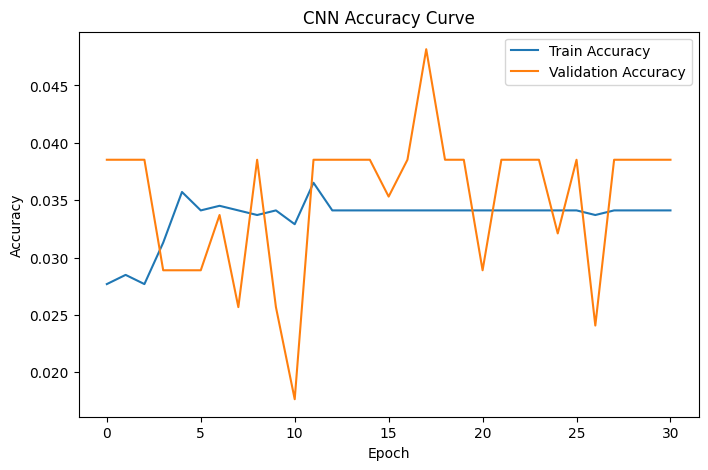

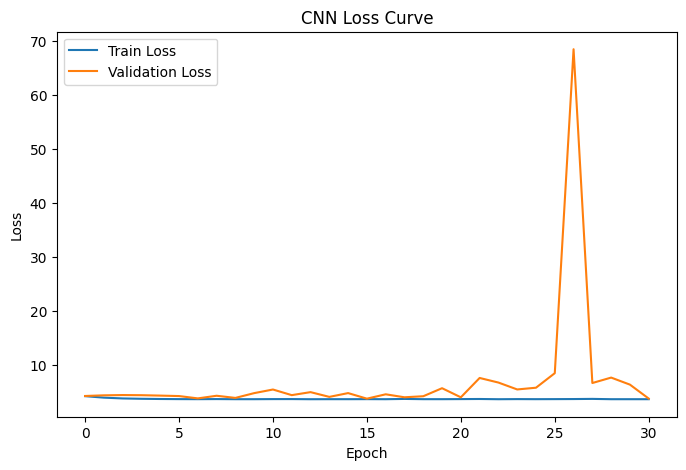

In [61]:
# Accurancy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("CNN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("CNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In conclusion, the custom CNN model achieved an accuracy of approximately 34%, indicating a significant underfitting issue due to the model's inability to fully capture the complex features of the fruit and vegetable varieties.

### Model Evaluation (Train &Test)

In [62]:
train_results = model.evaluate(x_train, y_train, verbose=0)
test_results = model.evaluate(x_test, y_test, verbose=0)

print("Train Results:")
print("Loss:", train_results[0])
print("Accuracy:", train_results[1])
print("Top-3 Accuracy:", train_results[2])

print("\nTest Results:")
print("Loss:", test_results[0])
print("Accuracy:", test_results[1])
print("Top-3 Accuracy:", test_results[2])

Train Results:
Loss: 3.698772430419922
Accuracy: 0.02648475207388401
Top-3 Accuracy: 0.08667736500501633

Test Results:
Loss: 3.688321352005005
Accuracy: 0.03531300276517868
Top-3 Accuracy: 0.08507223427295685


The custom CNN model demonstrated a clear case of underfitting, achieving a baseline training accuracy of 2.65% and a test accuracy of 3.53%. While the Top-3 Accuracy of approximately 8.51% suggests the model is attempting to capture some general features, the high loss values (Train: 3.70, Test: 3.69) indicate that the current architecture and preprocessing steps are insufficient to achieve high-precision classification across the 36 fruit and vegetable varieties

### Confusion Matrix for CNN

In [66]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 374ms/step


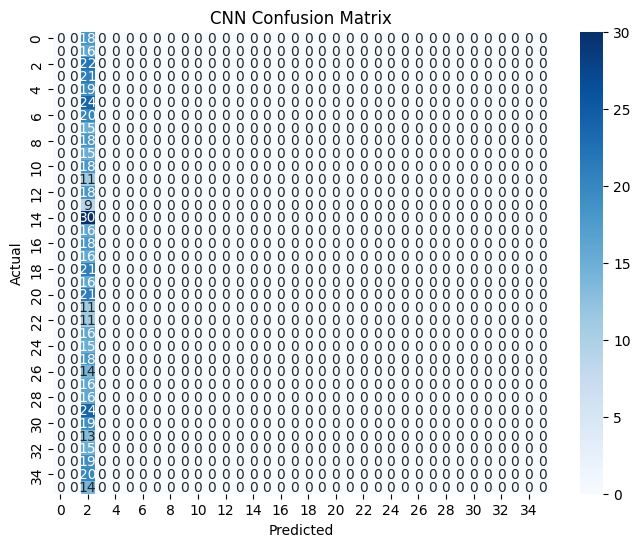

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        18
           1       0.00      0.00      0.00        16
           2       0.04      1.00      0.07        22
           3       0.00      0.00      0.00        21
           4       0.00      0.00      0.00        19
           5       0.00      0.00      0.00        24
           6       0.00      0.00      0.00        20
           7       0.00      0.00      0.00        15
           8       0.00      0.00      0.00        18
           9       0.00      0.00      0.00        15
          10       0.00      0.00      0.00        18
          11       0.00      0.00      0.00        11
          12       0.00      0.00      0.00        18
          13       0.00      0.00      0.00         9
          14       0.00      0.00      0.00        30
          15       0.00      0.00      0.00        16
          16       0.00      0.00      0.00        18
          17       0.00    

In [67]:
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step


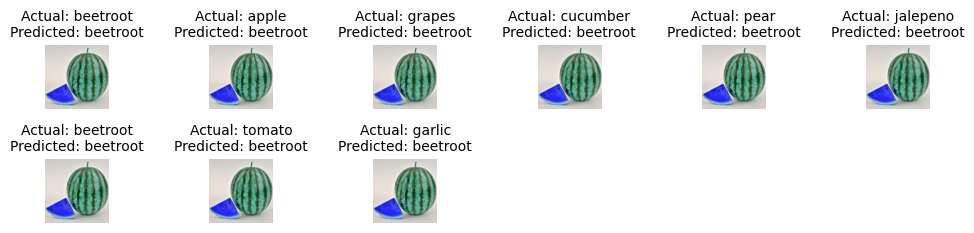

In [69]:
num_samples = len(x_test)
random_indices = np.random.choice(num_samples, size=min(9, len(x_test)), replace=False)

x_test_resized = x_test[random_indices]
y_test_array = np.array(y_test)
actual_labels = y_test_array[random_indices].flatten()

predictions = model.predict(x_test_resized)
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(10, 7))
for i, idx in enumerate(random_indices):
  plt.subplot(6,6, i+1)
  plt.imshow(x_test[idx])  
  plt.title(f"Actual: {labels[actual_labels[i]]}\nPredicted: {labels[predicted_labels[i]]}", fontsize=10)
  plt.axis('off')  
plt.tight_layout()  
plt.show()

The experimental results indicate a total failure in the model's convergence, as evidenced by a stagnant Test Accuracy of 3.53% (close to the random guessing baseline of 2.78% for 36 classes). A detailed analysis of the Confusion Matrix reveals a severe Class Collapse phenomenon, where the model outputs uniform or highly skewed predictions for a single dominant class regardless of the input's actual visual features.

The CNN Accuracy Curve exhibits high early volatility followed by a complete plateau, confirming that the network is suffering from extreme Underfitting. The high Loss values (~3.70 Train / ~3.69 Test) and completely flat performance metrics suggest that the custom architecture is unable to extract discriminative feature representations from the fruit and vegetable dataset. To resolve this, future iterations must leverage Transfer Learning (e.g., MobileNetV2 or ResNet50) and enhanced data augmentation techniques.

In [70]:
model.save('fruit_vegetable.h5')

### Transfer Learning

In [71]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.optimizers import Adam

In [75]:
data_dir = os.path.join(path, "train")
img_size = 224

datagen = ImageDataGenerator(preprocessing_function=preprocess_input,validation_split=0.20)

train_gen = datagen.flow_from_directory(data_dir,target_size=(img_size, img_size),class_mode='sparse',subset='training',shuffle=True)
val_gen = datagen.flow_from_directory(data_dir,target_size=(img_size, img_size),class_mode='sparse',subset='validation',shuffle=False)

Found 2510 images belonging to 36 classes.
Found 605 images belonging to 36 classes.


In [76]:
base_model = MobileNetV2(weights='imagenet',include_top=False,input_shape=(img_size, img_size, 3))
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step


In [78]:
model=Sequential()
model.add(base_model)  
model.add(GlobalAveragePooling2D())
model.add(Dense(512,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(36,activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.0001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [80]:
from tensorflow.keras.callbacks import EarlyStopping

In [81]:
early_stop = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

In [82]:
history2=model.fit(train_gen,epochs=50,validation_data=val_gen, callbacks=[early_stop])

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 180s 2s/step - accuracy: 0.1478 - loss: 3.3020 - val_accuracy: 0.5587 - val_loss: 2.3336
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.4498 - loss: 2.1998 - val_accuracy: 0.7421 - val_loss: 1.4384
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.6135 - loss: 1.5425 - val_accuracy: 0.7835 - val_loss: 0.9866
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.6908 - loss: 1.1976 - val_accuracy: 0.8215 - val_loss: 0.7619
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.7406 - loss: 0.9813 - val_accuracy: 0.8248 - val_loss: 0.6606
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.7645 - loss: 0.8478 - val_accuracy: 0.8496 - val_loss: 0.5836
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.7841 - loss: 0.7540 - val_accuracy: 0.8496 - val_loss: 0.5353
Epoch 8/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.8084 - loss: 0.6671 - val_accuracy: 0.8562 - v

In [83]:
history2.history['accuracy'][-1]

0.9697211384773254

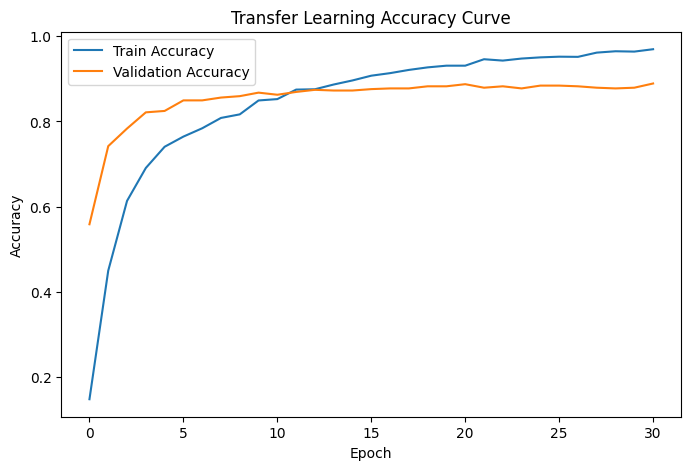

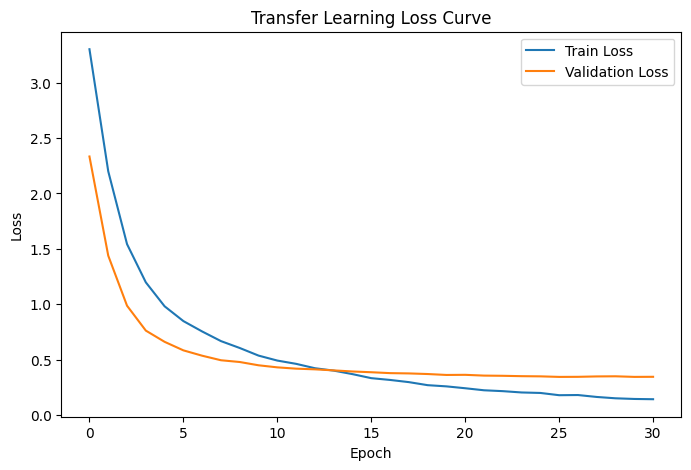

In [86]:
# Accurancy
plt.figure(figsize=(8,5))
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')

plt.title("Transfer Learning Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')

plt.title("Transfer Learning Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step


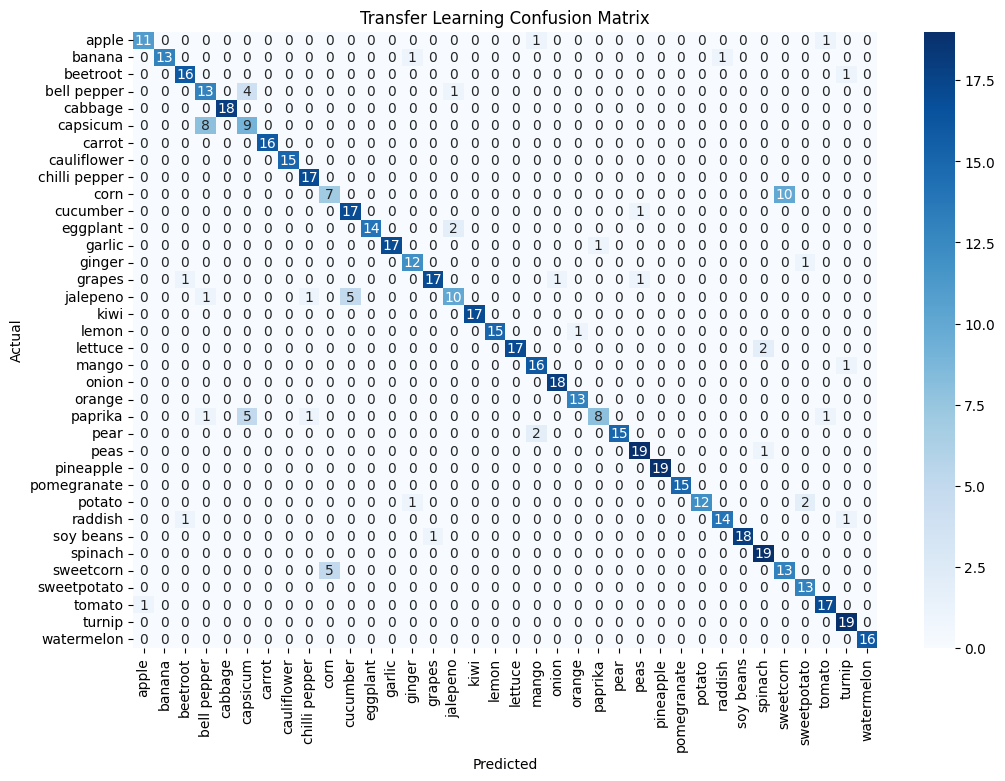

In [87]:
tahmin = model.predict(val_gen)
tahmin = np.argmax(tahmin, axis=1)

y_test = val_gen.classes

labels = list(val_gen.class_indices.keys())

plt.figure(figsize=(12,8))
sns.heatmap(confusion_matrix(y_test, tahmin),annot=True,cmap='Blues',xticklabels=labels,yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Transfer Learning Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━

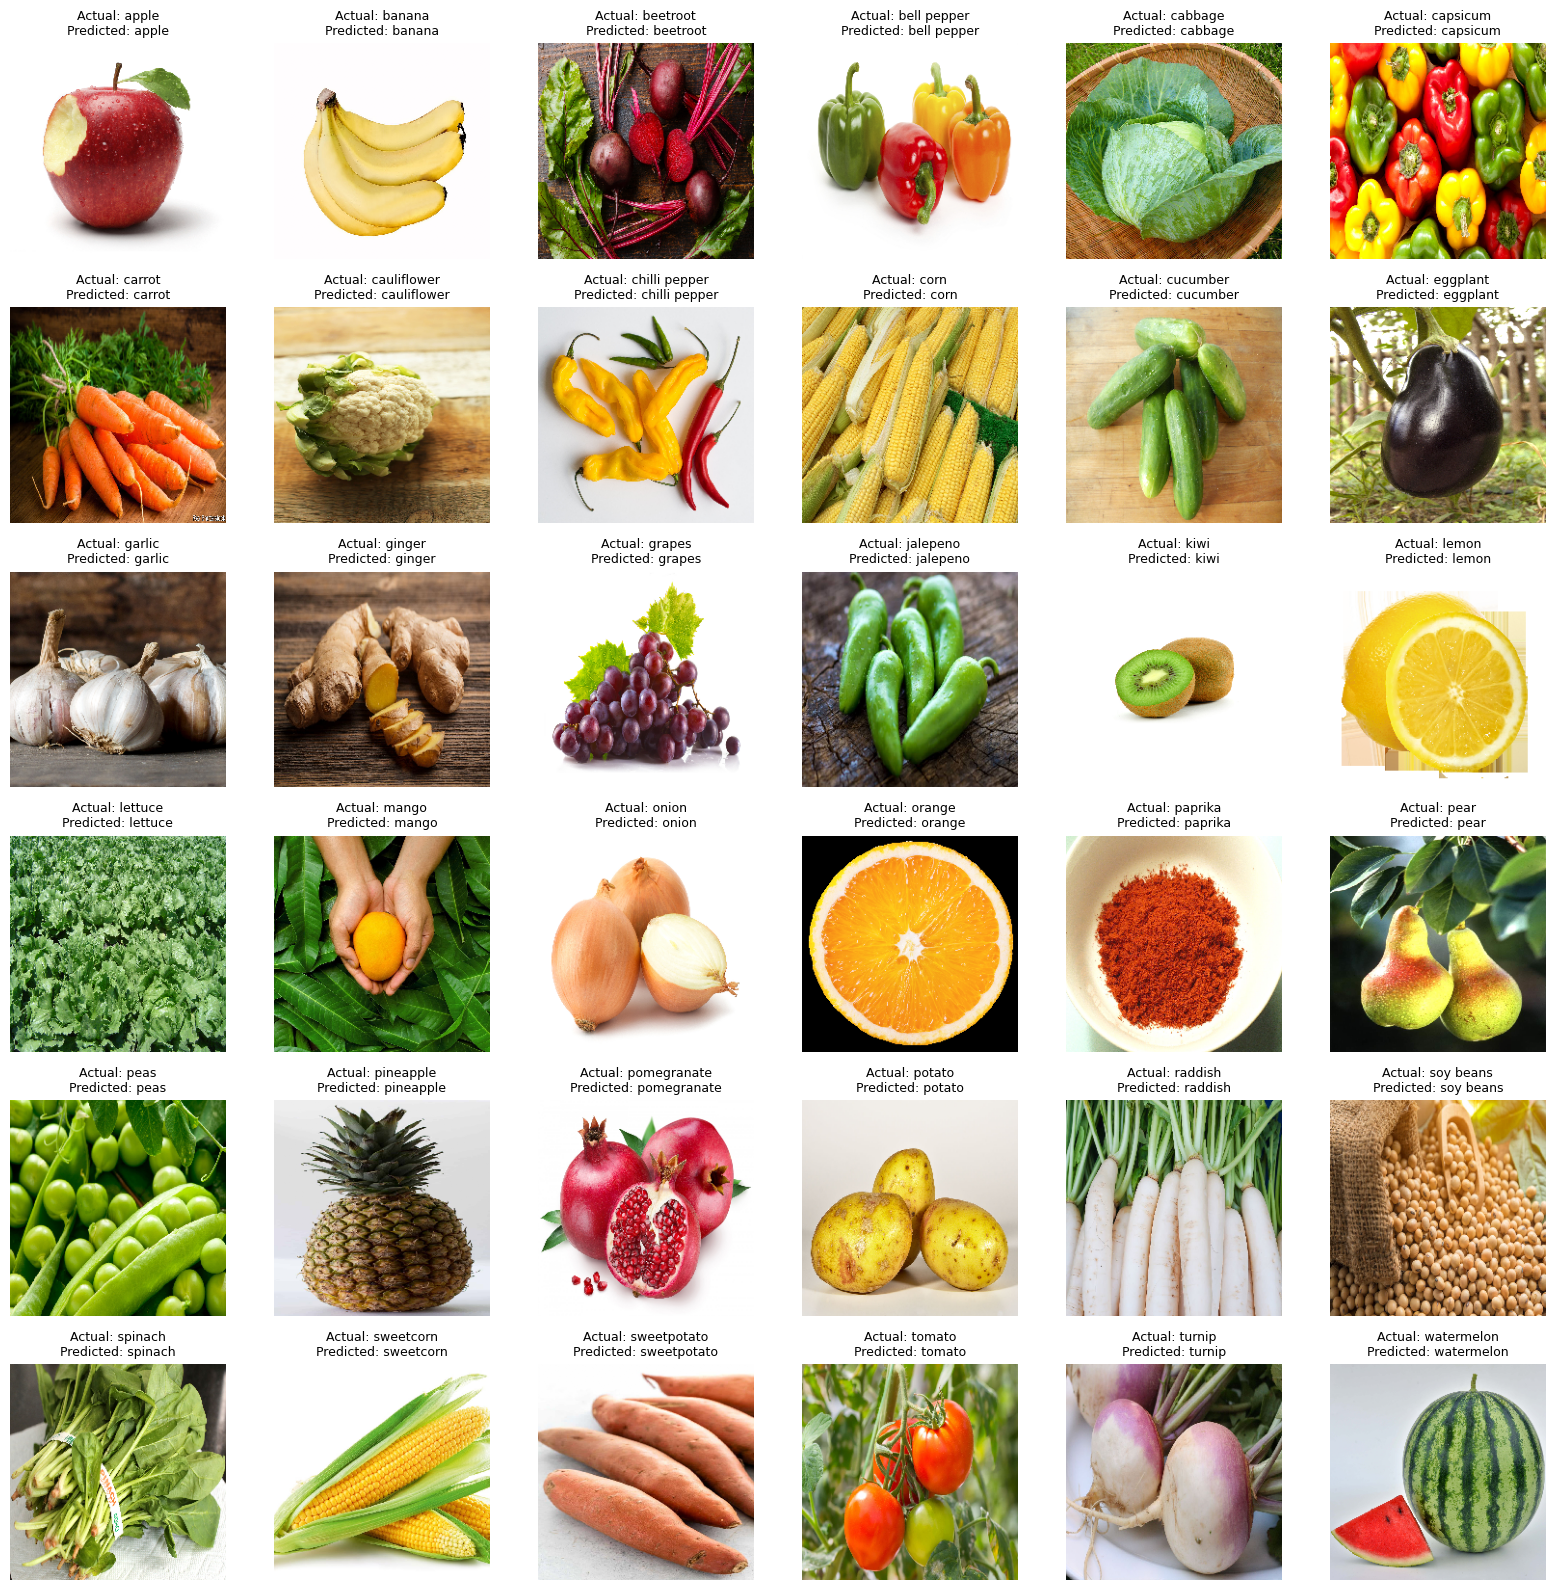

In [95]:
import numpy as np
import matplotlib.pyplot as plt

val_gen.reset()

x_all = []
y_all = []

for i in range(len(val_gen)):
    x_batch, y_batch = val_gen[i]
    x_all.append(x_batch)
    y_all.append(y_batch)

x_all = np.vstack(x_all)
y_all = np.hstack(y_all)

class_names = list(val_gen.class_indices.keys())
num_classes = len(class_names)

plt.figure(figsize=(16,16))

for class_id in range(num_classes):
    
    
    idx = np.where(y_all == class_id)[0][0]
    
    img = (x_all[idx] + 1) / 2
    
    prediction = model.predict(np.expand_dims(x_all[idx], axis=0))
    predicted_label = np.argmax(prediction)
    
    plt.subplot(6,6,class_id+1)
    plt.imshow(img)
    plt.title(
        f"Actual: {class_names[class_id]}\nPredicted: {class_names[predicted_label]}",
        fontsize=9
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

In [96]:
model.save("fruit_vegetable_transferlearning.h5")

In this study, two different deep learning approaches were applied to classify 36 different fruit and vegetable varieties. A custom Convolutional Neural Network (CNN) model achieved low validation accuracy (~3.53%), indicating insufficient feature extraction capability for complex visual patterns across a diverse dataset. In contrast, a Transfer Learning approach using MobileNetV2 significantly improved performance, achieving 96.97% validation accuracy. The confusion matrix demonstrated strong diagonal dominance, confirming robust class-level prediction performance across all 36 fruit and vegetable categories. The results clearly show that transfer learning with pretrained ImageNet weights provides superior generalization ability compared to training a CNN model from scratch, especially when dataset complexity is high. Therefore, Transfer Learning is recommended as the optimal approach for fruit and vegetable classification tasks.